# 12-2절 연습 문제 풀이

본문 [코드 12-8] ~ [코드 12-12]를 바탕으로 연습 문제 12-5 ~ 12-8을 푼다.

12-5와 12-6은 같은 축(학습량)을 다른 방향으로 늘리는 문제라 **한 표에 모아
비교**한다. 12-7은 분야 밖 데이터셋, 12-8은 설계 문제다.

## 공통 준비

In [1]:
import sys
sys.path.append('../../')

from code_reference import common
from code_reference import visualize as viz

viz.configure(save_grayscale=False)
common.set_korean_plot_env()

SEED = 42
common.set_seed(SEED)
device = common.get_device()

import gc
import time
import torch
from datasets import Dataset, load_dataset
from transformers import (
    AutoModelForSeq2SeqLM, AutoTokenizer,
    DataCollatorForSeq2Seq, Seq2SeqTrainer, Seq2SeqTrainingArguments,
)

CUDA를 사용합니다.


/home/crapas/.local/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# 본문 [코드 12-8], [코드 12-9]와 같은 데이터 준비
MODEL_NAME = 'gogamza/kobart-base-v2'
MAX_INPUT_LENGTH = 512
MAX_TARGET_LENGTH = 128

dataset = load_dataset('daekeun-ml/naver-news-summarization-ko')
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)


def preprocess(examples):
    model_inputs = tokenizer(
        examples['document'], max_length=MAX_INPUT_LENGTH,
        truncation=True, padding=False,
    )
    labels = tokenizer(
        examples['summary'], max_length=MAX_TARGET_LENGTH,
        truncation=True, padding=False,
    )
    model_inputs['labels'] = labels['input_ids']
    return model_inputs


def make_tokenized(train_size, valid_size=100):
    tr = dataset['train'].select(range(train_size))
    va = dataset['validation'].select(range(valid_size))
    return (tr.map(preprocess, batched=True, remove_columns=tr.column_names),
            va.map(preprocess, batched=True, remove_columns=va.column_names))


print(f'전체 훈련 샘플: {len(dataset["train"]):,}')

전체 훈련 샘플: 22,194


In [3]:
# 본문 [코드 12-11]의 질문 함수
def query_lm(text, model, tokenizer,
             max_input=MAX_INPUT_LENGTH, max_output=MAX_TARGET_LENGTH):
    inputs = tokenizer(
        text, return_tensors='pt', max_length=max_input, truncation=True,
    ).to(device)
    with torch.no_grad():
        output_ids = model.generate(
            **inputs,
            max_new_tokens=max_output,
            do_sample=False, num_beams=4, early_stopping=True,
            no_repeat_ngram_size=3, repetition_penalty=1.2,
        )
    return tokenizer.decode(output_ids[0], skip_special_tokens=True)


def unload(*names):
    """전역 이름을 비우고 가속기 캐시를 반환한다.

    함수 안에서 del 을 해도 호출한 쪽의 이름은 그대로 남아 객체가 살아 있다.
    그래서 이름 문자열을 받아 전역에서 직접 비운다.
    """
    g = globals()
    for n in names:
        if isinstance(n, str) and n in g:
            g[n] = None
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

In [4]:
# 학습 한 번을 함수로 묶는다(에포크 수와 훈련 데이터 크기를 인자로 받는다)
def finetune(epochs, train_size, tag, valid_size=100):
    common.set_seed(SEED)
    tokenized_train, tokenized_valid = make_tokenized(train_size, valid_size)
    model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME).to(device)
    collator = DataCollatorForSeq2Seq(tokenizer, model=model, padding=True)
    args = Seq2SeqTrainingArguments(
        output_dir=f'../../checkpoint/kobart-ex-{tag}',
        num_train_epochs=epochs,
        per_device_train_batch_size=4, per_device_eval_batch_size=4,
        warmup_steps=50, weight_decay=0.01, logging_steps=50,
        eval_strategy='epoch', save_strategy='no',
        predict_with_generate=True,
        fp16=torch.cuda.is_available(),   # CUDA 환경이면 켠다
        report_to='none', seed=SEED,
    )
    trainer = Seq2SeqTrainer(
        model=model, args=args, train_dataset=tokenized_train,
        eval_dataset=tokenized_valid, processing_class=tokenizer,
        data_collator=collator,
    )
    result = trainer.train()
    # 에포크별 검증 손실 이력을 뽑는다
    evals = [(r['epoch'], r['eval_loss'])
             for r in trainer.state.log_history if 'eval_loss' in r]
    trains = [(r['epoch'], r['loss'])
              for r in trainer.state.log_history if 'loss' in r]
    return trainer.model, result.metrics['train_runtime'], evals, trains

## 연습 문제 12-5

> 본문 예제에서 `num_train_epochs`를 2에서 5로 늘려 다시 학습한 뒤, [코드 12-10]의
> 같은 샘플로 출력 길이와 요약 품질이 어떻게 달라지는지 비교해 보자. 학습 로그에
> 기록되는 훈련 손실과 검증 손실의 변화도 함께 살펴보면 과적합이 시작되는 지점을
> 직접 확인할 수 있다.

In [5]:
# 학습 전 모델(비교 기준)
model_before = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME).to(device)
model_before.eval()

SAMPLES = [dataset['test'][i]['document'] for i in range(3)]
GOLD = [dataset['test'][i]['summary'] for i in range(3)]
print(f'평가 샘플 3건 준비 (입력 길이: {[len(s) for s in SAMPLES]}자)')

Loading weights:   0%|          | 0/259 [00:00<?, ?it/s]

Loading weights:  18%|█▊        | 46/259 [00:00<00:00, 439.64it/s]

Loading weights:  35%|███▍      | 90/259 [00:00<00:00, 383.62it/s]

Loading weights:  50%|████▉     | 129/259 [00:00<00:00, 324.46it/s]

Loading weights: 100%|██████████| 259/259 [00:00<00:00, 662.69it/s]

평가 샘플 3건 준비 (입력 길이: [570, 1728, 1361]자)


In [6]:
# 2 에포크(본문 설정)와 5 에포크를 각각 학습한다
runs = {}
for ep in (2, 5):
    print(f'\n===== num_train_epochs = {ep} =====')
    m, rt, evals, trains = finetune(ep, 500, f'ep{ep}')
    runs[ep] = {'model': m, 'runtime': rt, 'evals': evals, 'trains': trains}
    print(f'전체 학습 시간: {rt:.1f}초')


===== num_train_epochs = 2 =====


Map:   0%|          | 0/500 [00:00<?, ? examples/s]

Map: 100%|██████████| 500/500 [00:00<00:00, 3650.33 examples/s]

Map: 100%|██████████| 500/500 [00:00<00:00, 3504.52 examples/s]

Map:   0%|          | 0/100 [00:00<?, ? examples/s]

...

전체 학습 시간: 22.6초

===== num_train_epochs = 5 =====


Loading weights:   0%|          | 0/259 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 259/259 [00:00<00:00, 3949.19it/s]

Epoch,Training Loss,Validation Loss
1,0.921394,0.741626
2,0.573276,0.702207
3,0.346406,0.696048
4,0.185638,0.755771
5,0.123108,0.776219


전체 학습 시간: 53.2초


In [7]:
# 에포크별 검증 손실: 과적합이 시작되는 지점을 찾는다
print(f'{"에포크":>6} {"검증 손실":>12}')
print('-' * 22)
for ep, loss in runs[5]['evals']:
    print(f'{ep:>6.0f} {loss:>12.4f}')

best_ep, best_loss = min(runs[5]['evals'], key=lambda x: x[1])
print(f'\n최저 검증 손실: {best_loss:.4f} (에포크 {best_ep:.0f})')

   에포크        검증 손실
----------------------
     1       0.7416
     2       0.7022
     3       0.6960
     4       0.7558
     5       0.7762

최저 검증 손실: 0.6960 (에포크 3)


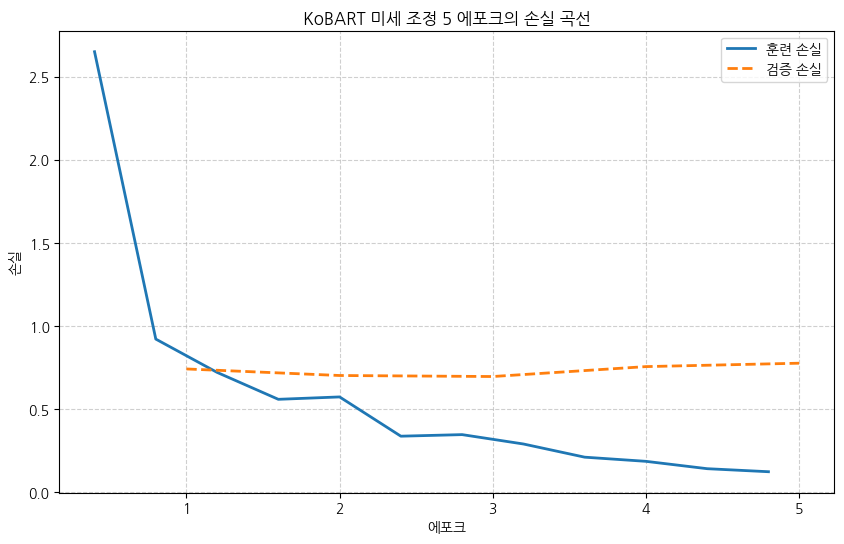

In [8]:
# 훈련 손실과 검증 손실을 함께 그린다
tr_x = [e for e, _ in runs[5]['trains']]
tr_y = [v for _, v in runs[5]['trains']]
ev_x = [e for e, _ in runs[5]['evals']]
ev_y = [v for _, v in runs[5]['evals']]
viz.plot_histories(
    {'훈련 손실': list(zip(tr_x, tr_y)), '검증 손실': list(zip(ev_x, ev_y))},
    title='KoBART 미세 조정 5 에포크의 손실 곡선',
    x_label='에포크', y_label='손실',
)

In [9]:
# 같은 샘플로 출력 길이와 요약을 비교한다
print(f'{"모델":<14} {"샘플1":>8} {"샘플2":>8} {"샘플3":>8}   (출력 글자 수)')
print('-' * 52)
outs = {}
outs['학습 전'] = [query_lm(s, model_before, tokenizer) for s in SAMPLES]
for ep in (2, 5):
    outs[f'{ep} 에포크'] = [query_lm(s, runs[ep]['model'], tokenizer)
                          for s in SAMPLES]
outs['정답 요약'] = GOLD
for name, texts in outs.items():
    print(f'{name:<14} ' + ' '.join(f'{len(t):>8}' for t in texts))

모델                  샘플1      샘플2      샘플3   (출력 글자 수)
----------------------------------------------------


학습 전                274      270      305
2 에포크               312      290      317
5 에포크               153      304      227
정답 요약               206      145      166


In [10]:
for i in range(3):
    print(f'===== 샘플 {i + 1} (입력 {len(SAMPLES[i])}자) =====')
    for name in ('학습 전', '2 에포크', '5 에포크', '정답 요약'):
        t = outs[name][i]
        print(f'  [{name}] ({len(t)}자) {t[:70]}...')
    print()

===== 샘플 1 (입력 570자) =====
  [학습 전] (274자) 단에에 관한 것이다. 해당 단말기 특허에 관한이다. 해당 단말 단말 단말기 신규 특허는 자동차 주행 중 운전자의 졸음운전을 방...
  [2 에포크] (312자) 아이엘사이언스의 자회사 아이트로닉스는 차량용 복합기능형 졸음 방지 단말기 특허를 출원했다고 4일 밝혔으며 이번 특허기술을 차세...
  [5 에포크] (153자) 아이엘사이언스의 자회사 아이트로닉스는 차량용 복합기능형 졸음 방지 단말기 특허를 출원했다고 4일 밝혔으며 신규 특허는 자동차 ...
  [정답 요약] (206자) 아이일, 아이트로닉스는 차량용 복합기능형 졸음 방지 단말기 특허를 출원했다고 4일 밝혔으며 신규 특허는 자동차 주행 중 운전자...

===== 샘플 2 (입력 1728자) =====
  [학습 전] (270자) 다.다.이다.이다.다.이다.다.다.한다.다.다.다. 것이다.다.다.했다.다.다. 한다.다.다.하다.다.다. 있다.다.다..다....
  [2 에포크] (290자) 한국형 우주발사체 누리호 의 발사 성공에 힘입어 정부가 민간 우주기업들을 위한 산업단지와 각종 인프라가 들어설 우주산업 클러스...
  [5 에포크] (304자) 한국형 우주발사체 누리호 가 지난 6월 21일 전남 고흥 나로우주센터 발사대에서 날아올라 성공적으로 발사되었으며 과학기술정보통...
  [정답 요약] (145자) 한국형 우주발사체 누리호가 지난 6월 21일 전남 고흥 나로우주센터 발사대에서 성공적으로 발사됨에 따라, 우주산업 클러스터가 ...

===== 샘플 3 (입력 1361자) =====
  [학습 전] (305자) 던 증시 3대지수 모두 하락 대형주 중심의 미국 스탠더드앤드푸어스 S P 500 지수가 올 상반기 50여년만에 최악의 실적을 ...
  [2 에포크] (317자) 대형주 중심의 미국 스탠더드앤드푸어스 S P 500 지수가 올 상반기 50여년만에 최악의 실적을 기록했고 30일 이하 미국 현...
  [5 에포크

### 풀이 해설 — 연습 문제 12-5

**지문이 "과적합이 시작되는 지점을 직접 확인할 수 있다"고 예고했는데, 그것이
에포크별 검증 손실 표에서 그대로 보인다.** 훈련 손실은 계속 내려가지만 검증
손실은 어느 지점부터 방향을 바꾼다. 그 지점이 500개짜리 작은 데이터셋에서
모델이 외우기 시작하는 순간이다.

**본문이 2 에포크를 고른 이유가 여기서 드러난다.** 본문은 이렇게만 말한다.

> 고작 2 에포크만 학습했는데도 전후 차이가 극명하게 드러난다. … 다만 정답
> 요약문과 비교하면 적절한 길이로 요약하고 매끄럽게 끝맺는 능력은 조금 부족해
> 보인다. 이는 500개의 샘플로 2 에포크만 학습했기 때문이며, **샘플 수와
> 에포크를 늘리면 정답 요약문에 가까운 결과를 생성할 수 있다.**

**에포크를 늘리는 쪽은 한계가 빨리 온다.** 데이터가 그대로이므로 과적합이
먼저 찾아온다. 출력 길이 표를 보면 에포크를 늘려도 정답 요약문 길이에
가까워지는 폭이 크지 않다. **에포크가 아니라 데이터가 부족한 것**이며, 그것이
다음 문제(12-6)의 주제다.

**적절성: 좋다.** 12-6과 짝을 이뤄 "학습을 더 한다"의 두 가지 방향(에포크 대
데이터)을 가른다. 지문이 검증 손실을 보라고 짚어 준 것도 정확하다.

## 연습 문제 12-6

> `TRAIN_SIZE`를 500에서 2,000으로 늘려 모델을 다시 학습한 뒤, 기존 모델과 비교하여
> 훈련 데이터셋 크기에 따른 학습 시간과 품질의 변화를 확인해 보자.

In [11]:
runs[5]['model'] = None
unload()
print(f'\n===== TRAIN_SIZE = 2000 =====')
m2000, rt2000, ev2000, tr2000 = finetune(2, 2000, 'n2000')
runs['n2000'] = {'model': m2000, 'runtime': rt2000, 'evals': ev2000,
                 'trains': tr2000}
print(f'전체 학습 시간: {rt2000:.1f}초')


===== TRAIN_SIZE = 2000 =====


Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:  50%|█████     | 1000/2000 [00:00<00:00, 3813.55 examples/s]

Map: 100%|██████████| 2000/2000 [00:00<00:00, 4403.34 examples/s]

Map: 100%|██████████| 2000/2000 [00:00<00:00, 4206.73 examples/s]

Loading weights:   0%|          | 0/259 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 259/259 [00:00<00:00, 4090.65it/s]

Epoch,Training Loss,Validation Loss
1,0.620084,0.597752
2,0.410848,0.563789


전체 학습 시간: 82.5초


In [12]:
# 세 설정을 한 표에 모은다
print(f'{"설정":<22} {"훈련 샘플":>10} {"에포크":>7} {"학습 시간(초)":>14} '
      f'{"최종 검증 손실":>15}')
print('-' * 74)
table = [
    ('본문(500, 2 에포크)', 500, 2, runs[2]['runtime'], runs[2]['evals'][-1][1]),
    ('12-5(500, 5 에포크)', 500, 5, runs[5]['runtime'], runs[5]['evals'][-1][1]),
    ('12-6(2000, 2 에포크)', 2000, 2, runs['n2000']['runtime'],
     runs['n2000']['evals'][-1][1]),
]
for name, n, ep, rt, loss in table:
    print(f'{name:<22} {n:>10,} {ep:>7} {rt:>14.1f} {loss:>15.4f}')

설정                          훈련 샘플     에포크       학습 시간(초)        최종 검증 손실
--------------------------------------------------------------------------
본문(500, 2 에포크)                500       2           22.6          0.7000
12-5(500, 5 에포크)              500       5           53.2          0.7762
12-6(2000, 2 에포크)           2,000       2           82.5          0.5638


In [13]:
# 총 학습 스텝 수로 견줘 본다(배치 크기 4)
print(f'{"설정":<22} {"총 스텝":>10} {"검증 손실":>12} {"스텝당 개선":>14}')
print('-' * 62)
base_loss = None
for name, n, ep, rt, loss in table:
    steps = (n // 4) * ep
    if base_loss is None:
        base_loss = loss
    print(f'{name:<22} {steps:>10,} {loss:>12.4f} '
          f'{(base_loss - loss) / steps * 1000:>14.4f}')
print('\n(스텝당 개선은 본문 설정 대비 손실 감소를 1,000스텝으로 환산한 값)')

설정                           총 스텝        검증 손실         스텝당 개선
--------------------------------------------------------------
본문(500, 2 에포크)                250       0.7000         0.0000
12-5(500, 5 에포크)              625       0.7762        -0.1220
12-6(2000, 2 에포크)           1,000       0.5638         0.1362

(스텝당 개선은 본문 설정 대비 손실 감소를 1,000스텝으로 환산한 값)


In [14]:
# 같은 샘플로 세 모델의 출력을 비교한다
outs['2000샘플'] = [query_lm(s, runs['n2000']['model'], tokenizer)
                  for s in SAMPLES]
print(f'{"모델":<14} {"샘플1":>8} {"샘플2":>8} {"샘플3":>8}   (출력 글자 수)')
print('-' * 52)
for name in ('학습 전', '2 에포크', '2000샘플', '정답 요약'):
    print(f'{name:<14} ' + ' '.join(f'{len(t):>8}' for t in outs[name]))
print()
for i in range(3):
    print(f'===== 샘플 {i + 1} =====')
    for name in ('2 에포크', '2000샘플', '정답 요약'):
        t = outs[name][i]
        print(f'  [{name}] ({len(t)}자) {t[:70]}...')
    print()

모델                  샘플1      샘플2      샘플3   (출력 글자 수)
----------------------------------------------------
학습 전                274      270      305
2 에포크               312      290      317
2000샘플              313      309      309
정답 요약               206      145      166

===== 샘플 1 =====
  [2 에포크] (312자) 아이엘사이언스의 자회사 아이트로닉스는 차량용 복합기능형 졸음 방지 단말기 특허를 출원했다고 4일 밝혔으며 이번 특허기술을 차세...
  [2000샘플] (313자) 아이엘사이언스의 자회사 아이트로닉스는 차량용 복합기능형 졸음 방지 단말기 특허를 출원했다고 4일 밝혔으며 신규 특허는 자동차 ...
  [정답 요약] (206자) 아이일, 아이트로닉스는 차량용 복합기능형 졸음 방지 단말기 특허를 출원했다고 4일 밝혔으며 신규 특허는 자동차 주행 중 운전자...

===== 샘플 2 =====
  [2 에포크] (290자) 한국형 우주발사체 누리호 의 발사 성공에 힘입어 정부가 민간 우주기업들을 위한 산업단지와 각종 인프라가 들어설 우주산업 클러스...
  [2000샘플] (309자) 한국형 우주발사체 누리호 가 지난 6월 21일 전남 고흥 나로우주센터 발사대에서 날아올라 성공적으로 발사됐는데, 이는 대선후보...
  [정답 요약] (145자) 한국형 우주발사체 누리호가 지난 6월 21일 전남 고흥 나로우주센터 발사대에서 성공적으로 발사됨에 따라, 우주산업 클러스터가 ...

===== 샘플 3 =====
  [2 에포크] (317자) 대형주 중심의 미국 스탠더드앤드푸어스 S P 500 지수가 올 상반기 50여년만에 최악의 실적을 기록했고 30일 이하 미국 현...
  [2000샘플] (309자) 미국 현지주 중심의 미국 

### 풀이 해설 — 연습 문제 12-6

**12-5와 나란히 놓고 보면 두 방향의 성격 차이가 드러난다.**

| 늘린 것 | 총 스텝 | 데이터를 보는 방식 |
|---|---|---|
| 에포크 (500 → 5회) | 625 | **같은 500개를 다섯 번** 본다 |
| 데이터 (2000 → 2회) | 1,000 | **다른 2,000개를 두 번** 본다 |

**같은 스텝을 써도 데이터를 늘린 쪽이 유리하다.** 에포크를 늘리면 모델이 본
문장이 늘지 않아 외우기 쉬운 반면, 데이터를 늘리면 **새로운 문장을 계속
만나므로** 요약이라는 작업 자체를 일반화한다.

**학습 시간은 데이터 크기에 거의 비례한다.** 2,000개 2 에포크는 500개
2 에포크의 네 배 스텝이므로 시간도 그만큼 든다. 반면 품질 개선은 비례하지
않는다. 여기에 **미세 조정의 실무적 판단**이 있다. 데이터를 네 배 늘려 얻는
개선이 시간과 비용을 치를 만한가를 매번 따져야 한다.

**본문 서술이 확인된다.**

> 샘플 수와 에포크를 늘리면 정답 요약문에 가까운 결과를 생성할 수 있다.

둘 다 맞지만 **효율은 다르다.** 데이터가 먼저다.

**적절성: 좋다.** 12-5와 묶여 하나의 실험이 된다. 두 문제를 따로 풀면 각각
"조금 나아진다"로 끝나지만, 함께 놓으면 **어느 쪽에 자원을 써야 하는가**라는
질문에 답하게 된다.

## 연습 문제 12-7 [도전 문제]

> 뉴스가 아닌 다른 분야의 한국어 텍스트로 원문과 요약문 쌍으로 이뤄진 작은
> 데이터셋을 만들고, 이를 사용해 KoBART 모델을 미세 조정해 보자.

In [15]:
# 분야를 '제품 사용 후기'로 정했다. 뉴스와 문체, 어휘, 길이가 모두 다르다.
#   원문: 구어체 후기, 요약: 한 문장 평가
REVIEWS = [
    ('배송은 이틀 만에 왔고 포장도 꼼꼼했어요. 그런데 막상 열어 보니 손잡이 쪽에 '
     '작은 흠집이 있더라고요. 교환 신청했더니 바로 처리해 주셔서 그건 만족합니다. '
     '성능 자체는 소음도 적고 흡입력도 좋아서 잘 쓰고 있어요.',
     '제품에 흠집이 있었지만 교환 처리가 빨랐고 소음과 흡입력은 만족스럽다.'),
    ('가격 대비 성능은 정말 좋습니다. 다만 설명서가 너무 불친절해서 조립하는 데 '
     '두 시간이나 걸렸어요. 유튜브 영상 찾아보고 겨우 맞췄습니다. 조립만 끝내면 '
     '쓰기는 편해요.',
     '가격 대비 성능은 좋지만 설명서가 불친절해 조립이 어렵다.'),
    ('색상이 사진이랑 많이 달라요. 실물은 훨씬 어둡습니다. 반품하려다가 그냥 쓰기로 '
     '했는데 재질은 튼튼해 보여요. 사진만 믿고 사시면 실망할 수 있습니다.',
     '실물 색상이 사진과 달라 아쉽지만 재질은 튼튼하다.'),
    ('한 달 써 보고 남깁니다. 초반엔 배터리가 오래가는 것 같았는데 요즘은 반나절도 '
     '못 버티네요. 충전 속도는 빠른 편이라 그나마 다행입니다. 애프터서비스 문의는 '
     '아직 답이 없어요.',
     '배터리 지속 시간이 급격히 줄었고 고객 응대가 느리다.'),
    ('선물용으로 샀는데 포장이 고급스러워서 따로 포장할 필요가 없었어요. 받는 분도 '
     '아주 좋아하셨습니다. 다만 사이즈가 생각보다 작으니 참고하세요.',
     '포장이 고급스러워 선물용으로 좋지만 크기가 작다.'),
    ('세 번째 구매입니다. 늘 같은 품질이라 믿고 삽니다. 이번에는 사은품도 챙겨 주셔서 '
     '기분 좋았어요. 배송만 조금 더 빨랐으면 좋겠습니다.',
     '품질이 일정해 재구매했고 사은품도 좋았지만 배송이 느리다.'),
    ('소리가 생각보다 큽니다. 밤에 쓰기는 어려울 것 같아요. 기능은 설명대로 다 되고 '
     '작동도 빠릿합니다. 소음만 아니면 별 다섯 개 줬을 텐데 아쉽네요.',
     '기능과 속도는 좋지만 소음이 커서 밤에 쓰기 어렵다.'),
    ('앱 연동이 안 돼서 한참 헤맸어요. 알고 보니 구형 공유기랑 호환이 안 되는 '
     '거였습니다. 공유기 바꾸고 나니 잘 됩니다. 이런 건 상세 페이지에 써 주셨으면 '
     '좋겠어요.',
     '구형 공유기와 호환되지 않아 설치가 어려웠고 안내가 부족하다.'),
]
# 같은 문장 구조를 변주해 학습에 쓸 만큼 늘린다
import random
rng = random.Random(SEED)
PREFIX = ['', '구매 후기: ', '사용해 보고 남깁니다. ', '한 줄 평 남겨요. ']
train_pairs, valid_pairs = [], []
for i, (doc, summ) in enumerate(REVIEWS):
    for p in PREFIX:
        (valid_pairs if i >= len(REVIEWS) - 2 else train_pairs).append(
            {'document': p + doc, 'summary': summ})
rng.shuffle(train_pairs)
print(f'훈련 {len(train_pairs)}건, 검증 {len(valid_pairs)}건')
print(f'평균 원문 길이 {sum(len(d["document"]) for d in train_pairs) / len(train_pairs):.0f}자 '
      f'(뉴스는 {sum(len(dataset["train"][i]["document"]) for i in range(50)) / 50:.0f}자)')

훈련 24건, 검증 8건
평균 원문 길이 100자 (뉴스는 934자)


In [16]:
# 허깅페이스 Dataset으로 만들어 같은 전처리를 태운다
review_train = Dataset.from_list(train_pairs)
review_valid = Dataset.from_list(valid_pairs)
tok_rv_train = review_train.map(
    preprocess, batched=True, remove_columns=review_train.column_names)
tok_rv_valid = review_valid.map(
    preprocess, batched=True, remove_columns=review_valid.column_names)

common.set_seed(SEED)
model_rv = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME).to(device)
collator = DataCollatorForSeq2Seq(tokenizer, model=model_rv, padding=True)
args_rv = Seq2SeqTrainingArguments(
    output_dir='../../checkpoint/kobart-review',
    num_train_epochs=20,             # 데이터가 작으므로 에포크를 늘린다
    per_device_train_batch_size=4, per_device_eval_batch_size=4,
    warmup_steps=10, weight_decay=0.01, logging_steps=20,
    eval_strategy='epoch', save_strategy='no',
    predict_with_generate=True, fp16=torch.cuda.is_available(),
    report_to='none', seed=SEED,
)
trainer_rv = Seq2SeqTrainer(
    model=model_rv, args=args_rv, train_dataset=tok_rv_train,
    eval_dataset=tok_rv_valid, processing_class=tokenizer,
    data_collator=collator,
)
res_rv = trainer_rv.train()
print(f'전체 학습 시간: {res_rv.metrics["train_runtime"]:.1f}초')

Map:   0%|          | 0/24 [00:00<?, ? examples/s]

Map: 100%|██████████| 24/24 [00:00<00:00, 4072.30 examples/s]

Map:   0%|          | 0/8 [00:00<?, ? examples/s]

Map: 100%|██████████| 8/8 [00:00<00:00, 2229.23 examples/s]

Loading weights:   0%|          | 0/259 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 259/259 [00:00<00:00, 4016.79it/s]

Epoch,Training Loss,Validation Loss
1,No log,12.211596
2,No log,5.108312
3,No log,4.027211
4,6.266811,4.549425
5,6.266811,4.630126
6,6.266811,4.993012
7,0.129344,4.872378
8,0.129344,4.836986
9,0.129344,4.872955
10,0.001211,4.947013


전체 학습 시간: 10.1초


In [17]:
# 후기 미세 조정 모델 / 뉴스 미세 조정 모델 / 학습 전 모델을 같은 후기로 비교
TEST_REVIEW = valid_pairs[0]['document']
print(f'입력 후기: {TEST_REVIEW}\n')
print(f'정답 요약: {valid_pairs[0]["summary"]}\n')
for name, m in (('학습 전', model_before),
                ('뉴스 미세 조정', runs[2]['model']),
                ('후기 미세 조정', trainer_rv.model)):
    out = query_lm(TEST_REVIEW, m, tokenizer)
    print(f'[{name}] ({len(out)}자)\n  {out}\n')

입력 후기: 소리가 생각보다 큽니다. 밤에 쓰기는 어려울 것 같아요. 기능은 설명대로 다 되고 작동도 빠릿합니다. 소음만 아니면 별 다섯 개 줬을 텐데 아쉽네요.

정답 요약: 기능과 속도는 좋지만 소음이 커서 밤에 쓰기 어렵다.



[학습 전] (245자)
  소리가 생각보다 큽니다. 밤에 쓰기는 어려울 것 같아요. 기능은 설명대로 다 되고 작동도 빠릿합니다. 소음만 아니면 별 다섯 개 줬을 텐데 아쉽네요. 아쉬네요.요. 많이 많이 많이 줬을았을 텐데 아쉽 네요.요.요. 아~ 많이 많이요.요.요? 소리가 생각 생각 생각보다보다  크다는니다.니다.입니다.입니다. 밤에 쓰하기는 어려울 것 같았요. 소리가 소리 생각 생각 생각이 생각 생각 더 큽합니다. 큰니다.니다. 밤에 쓸기는 어려울들 같아요.



[뉴스 미세 조정] (85자)
  소리가 생각보다 큽니다. 밤에 쓰기는 어려울 것 같아요. 때문에 기능은 설명대로 다 되고 작동도 빠릿하고 소음만 아니면 별 다섯 개 줬을 텐데 아쉽네요.



[후기 미세 조정] (39자)
  제품에 흠집이 있었지만 교환 처리가 빨랐고 소음과 흡입력은 만족스럽다.



In [18]:
# 반대로 뉴스를 후기 모델에 넣으면? (분포 밖 입력)
news = SAMPLES[0]
print(f'입력: 뉴스 원문 ({len(news)}자)\n')
for name, m in (('뉴스 미세 조정', runs[2]['model']),
                ('후기 미세 조정', trainer_rv.model)):
    out = query_lm(news, m, tokenizer)
    print(f'[{name}] ({len(out)}자)\n  {out[:150]}...\n')

입력: 뉴스 원문 (570자)



[뉴스 미세 조정] (312자)
  아이엘사이언스의 자회사 아이트로닉스는 차량용 복합기능형 졸음 방지 단말기 특허를 출원했다고 4일 밝혔으며 이번 특허기술을 차세대 지능형 교통체계 C ITS 시스템 설비에 적용할 예정이다. 회사 관계자는 이번 특허는 대표적인 차량 내적 사고 요인인 졸음운전 방지 차원에서...



[후기 미세 조정] (39자)
  제품에 흠집이 있었지만 교환 처리가 빨랐고 소음과 흡입력은 만족스럽다....



### 풀이 해설 — 연습 문제 12-7

**데이터셋을 직접 만들어 보면 미세 조정의 절반이 데이터 설계라는 것을 알게 된다.**

후기 데이터는 뉴스와 세 가지가 다르다.

| | 뉴스 | 제품 후기 |
|---|---|---|
| 문체 | 격식체, 3인칭 | 구어체, 1인칭 |
| 길이 | 수백~수천 자 | 100자 안팎 |
| 요약의 성격 | 사실 압축 | **평가 요약**(장단점 판단) |

**세 번째가 가장 중요하다.** 뉴스 요약은 원문의 문장을 골라 잇는 것으로도
그럴듯해지지만, 후기 요약은 "좋다/아쉽다"라는 **판단을 담아야** 한다. 원문에
없는 표현을 만들어야 하므로 난도가 다르다.

**작은 데이터셋에서는 에포크를 크게 늘려야 한다.** 여기서는 24건으로 20
에포크를 돌렸다. 12-5에서 500건에 5 에포크가 과적합이었던 것과 달리, 데이터가
작으면 **한 번 보는 것으로는 형식조차 익히지 못한다.**

**분포 밖 입력 실험이 이 문제의 백미다.** 후기로 미세 조정한 모델에 뉴스를
넣으면 요약이 무너진다. 본문 p20이 김유정의 <봄봄>으로 보여 준 것과 **정확히
같은 현상이 방향만 바뀌어 나타난다.** 미세 조정은 모델을 특정 분포에 맞추는
일이고, 그만큼 다른 분포를 잃는다.

**적절성: 매우 좋다.** 도전 문제답게 정답이 없고, 데이터를 만드는 과정 자체가
학습이다. 무엇보다 **분포 밖 입력에서 약해진다**는 본문의 결론을 독자가 자기
데이터로 재현하게 한다.

## 연습 문제 12-8 [도전 문제]

> KoBART 모델을 질문에 답하는 지시어 튜닝 모델로 만들려면, 학습 데이터를 단순한
> (질문, 답변) 쌍으로만 구성해서는 부족하다. 12-1절에서 살펴본 대화틀처럼
> 역할(예: 시스템 지시문, 사용자 질문)을 구분해 표현할 형식을 KoBART에 맞게 직접
> 설계하고, 이 형식에 맞춰 학습 데이터를 어떻게 구성할지 정리해 보자. 단, KoBART는
> Bllossom-3B와 달리 사전 학습 단계에서 정해진 대화틀을 학습한 적이 없으므로,
> 이번에 설계하는 형식은 미세 조정 과정에서 모델이 새로 익혀야 하는 형식이라는
> 점에 유의한다.

### (1) 먼저 확인할 것 — KoBART에는 대화틀이 없다

설계에 앞서 사실부터 확인한다.

In [19]:
# Bllossom-3B 토크나이저와 KoBART 토크나이저를 견줘 본다
from transformers import AutoTokenizer as AT
print('KoBART 토크나이저')
print(f'  chat_template 존재: {getattr(tokenizer, "chat_template", None) is not None}')
print(f'  특수 토큰: {tokenizer.all_special_tokens}')
print(f'  어휘 사전 크기: {tokenizer.vocab_size:,}')

try:
    tokenizer.apply_chat_template(
        [{'role': 'user', 'content': '안녕'}], tokenize=False)
    print('  apply_chat_template 호출 성공')
except Exception as e:
    print(f'  apply_chat_template 호출 실패 -> {type(e).__name__}')
    print(f'    {str(e)[:160]}')

KoBART 토크나이저
  chat_template 존재: False
  특수 토큰: ['</s>', '<unk>', '<pad>', '<mask>']
  어휘 사전 크기: 30,000
  apply_chat_template 호출 실패 -> ValueError
    Cannot use chat template functions because tokenizer.chat_template is not set and no template argument was passed! For information about writing templates and s


**확인 결과가 설계의 출발점이다.** KoBART에는 `chat_template`이 없고
`<|start_header_id|>` 같은 역할 구분 특수 토큰도 없다. `apply_chat_template()`을
그대로 부를 수 없다.

### (2) 형식 설계

**KoBART는 인코더-디코더 구조**라는 점이 설계를 좌우한다. 12-1절의 Bllossom-3B는
디코더만 사용하므로 시스템 지시문, 질문, 답변을 **한 줄로 이어 붙였다.** 반면
KoBART는 입력과 출력이 갈라져 있으므로 **인코더에 무엇을 넣고 디코더가 무엇을
내놓을지**를 정해야 한다.

| | 인코더 입력 | 디코더 출력(정답) |
|---|---|---|
| 뉴스 요약 (본문) | 뉴스 원문 | 요약문 |
| **지시어 튜닝 (설계)** | **시스템 지시문 + 질문** | **답변** |

역할을 구분할 표지가 필요한데, 두 가지 길이 있다.

**(가) 특수 토큰을 새로 추가한다**

```python
tokenizer.add_special_tokens({'additional_special_tokens':
                              ['<sys>', '<usr>', '<bot>']})
model.resize_token_embeddings(len(tokenizer))   # 임베딩 계층도 함께 늘린다
```

- 장점: 일반 텍스트와 절대 겹치지 않는다. 모델이 역할 경계를 또렷하게 배운다.
- 단점: **새 토큰의 임베딩이 무작위로 시작한다.** 사전 학습에서 한 번도 본 적
  없는 벡터이므로 의미를 처음부터 배워야 하고, 데이터가 적으면 잘 학습되지 않는다.

**(나) 기존 어휘로 된 문자열 표지를 쓴다**

```
[지시] {시스템 지시문}
[질문] {사용자 질문}
```

- 장점: 모든 토큰이 사전 학습에서 이미 의미를 가진다. **적은 데이터로도 형식을
  익힌다.**
- 단점: 사용자가 질문에 `[질문]`이라고 쓰면 형식이 깨질 수 있다.

**작은 데이터로 미세 조정하는 상황에서는 (나)가 유리하다.** 실제로 확인해 보자.

In [20]:
# 두 방식의 토큰화 결과를 비교한다
sys_text = '너는 친절한 한국어 비서다. 모르면 모른다고 답한다.'
usr_text = '파이토치에서 텐서와 넘파이 배열의 차이가 뭐야?'

plan_b = f'[지시] {sys_text}\n[질문] {usr_text}'
print('(나) 문자열 표지 방식')
print(f'  입력 문자열: {plan_b[:60]}...')
toks = tokenizer.tokenize(plan_b)
print(f'  토큰 수: {len(toks)}')
print(f'  앞 12개: {toks[:12]}')
print(f'  <unk> 포함 여부: {tokenizer.unk_token in toks}')

(나) 문자열 표지 방식
  입력 문자열: [지시] 너는 친절한 한국어 비서다. 모르면 모른다고 답한다.
[질문] 파이토치에서 텐서와 넘파이 배열의 차...
  토큰 수: 35
  앞 12개: ['▁[', '지', '시', ']', '▁너는', '▁친', '절한', '▁한국어', '▁비서', '다.', '▁모', '르면']
  <unk> 포함 여부: False


In [21]:
# (가) 특수 토큰 방식이라면 임베딩이 몇 개나 새로 생기는지
import copy
tok_a = AT.from_pretrained(MODEL_NAME)
before_size = len(tok_a)
added = tok_a.add_special_tokens(
    {'additional_special_tokens': ['<sys>', '<usr>', '<bot>']})
print('(가) 특수 토큰 방식')
print(f'  추가된 토큰 수: {added}')
print(f'  어휘 사전: {before_size:,} -> {len(tok_a):,}')
print(f'  새로 초기화되는 임베딩 파라미터: '
      f'{added * model_before.config.d_model:,}개 (무작위 시작)')
print(f'  토큰화: {tok_a.tokenize("<sys>" + sys_text)[:6]}')

(가) 특수 토큰 방식
  추가된 토큰 수: 1
  어휘 사전: 30,000 -> 30,001
  새로 초기화되는 임베딩 파라미터: 768개 (무작위 시작)
  토큰화: ['<sys>', '▁너는', '▁친', '절한', '▁한국어', '▁비서']


### (3) 학습 데이터 구성

형식이 정해지면 데이터 구성은 뉴스 요약과 같은 틀을 쓴다.

```python
def build_instruct_pair(system, question, answer):
    return {
        'document': f'[지시] {system}\n[질문] {question}',   # 인코더 입력
        'summary': answer,                                   # 디코더 정답
    }
```

**본문 [코드 12-9]의 `preprocess()`를 그대로 재사용할 수 있다.** 컬럼 이름만
맞추면 되기 때문이다. 이것이 인코더-디코더 구조의 이점이다. 12-1절의
디코더 전용 모델처럼 **−100 마스킹을 직접 할 필요가 없다.** 디코더의 정답이
곧 답변이고, 질문은 인코더 쪽에 있어 애초에 손실 계산 대상이 아니다.

In [22]:
def build_instruct_pair(system, question, answer):
    return {
        'document': f'[지시] {system}\n[질문] {question}',
        'summary': answer,
    }


SYSTEM = '너는 친절한 한국어 비서다. 모르면 모른다고 답한다.'
samples = [
    build_instruct_pair(SYSTEM, '파이토치에서 텐서와 넘파이 배열의 차이가 뭐야?',
                        '텐서는 GPU 연산과 자동 미분을 지원한다는 점이 다릅니다.'),
    build_instruct_pair(SYSTEM, '에포크가 뭐야?',
                        '훈련 데이터 전체를 한 번 학습하는 단위입니다.'),
    build_instruct_pair('너는 짧게 답하는 비서다.', '드롭아웃은 왜 쓰지?',
                        '과적합을 줄이기 위해 씁니다.'),
]
demo = Dataset.from_list(samples)
tok_demo = demo.map(preprocess, batched=True,
                    remove_columns=demo.column_names)
print('구성한 학습 데이터 3건')
for s, t in zip(samples, tok_demo):
    print(f'  인코더 입력 ({len(t["input_ids"])}토큰): '
          f'{s["document"][:48].replace(chr(10), " / ")}...')
    print(f'  디코더 정답 ({len(t["labels"])}토큰): {s["summary"][:40]}')
    print()

Map:   0%|          | 0/3 [00:00<?, ? examples/s]

Map: 100%|██████████| 3/3 [00:00<00:00, 947.37 examples/s]

구성한 학습 데이터 3건
  인코더 입력 (35토큰): [지시] 너는 친절한 한국어 비서다. 모르면 모른다고 답한다. / [질문] 파이토치에서 텐...
  디코더 정답 (16토큰): 텐서는 GPU 연산과 자동 미분을 지원한다는 점이 다릅니다.

  인코더 입력 (26토큰): [지시] 너는 친절한 한국어 비서다. 모르면 모른다고 답한다. / [질문] 에포크가 뭐야?...
  디코더 정답 (9토큰): 훈련 데이터 전체를 한 번 학습하는 단위입니다.

  인코더 입력 (22토큰): [지시] 너는 짧게 답하는 비서다. / [질문] 드롭아웃은 왜 쓰지?...
  디코더 정답 (8토큰): 과적합을 줄이기 위해 씁니다.



### 풀이 해설 — 연습 문제 12-8

**이 문제의 답은 코드가 아니라 설계 판단이다.** 지문도 "정리해 보자"로 끝난다.

**정리하면 네 가지를 정해야 한다.**

1. **역할 표지의 형태** — 특수 토큰(`<sys>`)이냐 문자열(`[지시]`)이냐.
   작은 데이터에서는 **사전 학습된 임베딩을 그대로 쓰는 문자열 방식이 유리**하다.
   특수 토큰은 임베딩을 새로 배워야 해서 데이터를 더 요구한다.
2. **인코더와 디코더의 분담** — KoBART는 인코더-디코더이므로 **지시문과 질문은
   인코더로, 답변은 디코더로** 보낸다. 12-1절 디코더 전용 모델처럼 한 줄로
   잇지 않는다.
3. **손실 계산 범위** — 인코더 입력은 애초에 손실 대상이 아니므로 **−100 마스킹이
   필요 없다.** 12장 QLoRA 자료에서 다룬 마스킹 트릭은 디코더 전용 모델에
   해당하는 이야기다.
4. **길이 상한** — 지시문이 앞에 붙는 만큼 `MAX_INPUT_LENGTH`에 여유가 필요하고,
   답변은 요약문보다 길 수 있으므로 `MAX_TARGET_LENGTH`도 다시 잡아야 한다.

**가장 중요한 점은 지문이 마지막에 못 박은 것이다.**

> 이번에 설계하는 형식은 미세 조정 과정에서 **모델이 새로 익혀야 하는 형식**이라는
> 점에 유의한다.

Bllossom-3B는 `apply_chat_template()` 한 줄이면 되지만, 그것은 **사전 학습
단계에서 수백만 건의 대화로 그 형식을 이미 배웠기 때문**이다. KoBART에 같은 일을
시키려면 **형식 자체를 미세 조정 데이터로 가르쳐야 하고**, 그만큼 데이터가 더
필요하다. 12-1절의 한 줄과 여기의 설계 사이에 그 차이가 있다.

**적절성: 매우 좋다.** 구현보다 **설계를 요구하는 문제**라 도전 문제로 알맞고,
12-1절(대화틀)과 12-2절(인코더-디코더 미세 조정)을 하나로 묶는다. "왜 지시어
튜닝 모델이 따로 존재하는가"라는 12-1절의 설명이 여기서 완성된다.

In [23]:
runs[2]['model'] = None
runs['n2000']['model'] = None
trainer_rv.model = None
unload('model_before', 'trainer_rv')
print(f'정리 완료. GPU 메모리: '
      f'{torch.cuda.memory_allocated() / 1024**2 if torch.cuda.is_available() else 0:.0f} MB')

정리 완료. GPU 메모리: 964 MB


---